### Standardization

In [11]:
# import the packages
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [12]:
# Load the data 
df = pd.read_csv("Social_Network_Ads.csv")

In [13]:
# extract all row and age , estimated salary, Purchased Column
df = df.iloc[:,2:]

df.sample(5)

,Age,EstimatedSalary,Purchased
351,37,75000,0
312,38,50000,0
158,26,30000,0
386,49,39000,1
188,35,72000,0


In [14]:
# Split the 70% train data and 30 % test data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.drop("Purchased", axis=1), df["Purchased"], test_size=0.3, random_state=0 )

x_train.shape, x_test.shape

((280, 2), (120, 2))

In [15]:
from sklearn.preprocessing import StandardScaler

# Create StandardScaler object
scaler = StandardScaler()

# Learn mean and standard deviation from training data
scaler.fit(x_train)

# Transform training data using learned values
x_train_scaled = scaler.transform(x_train)

# Transform test data using same mean and std from training data
x_test_scaled = scaler.transform(x_test)

In [16]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [ ]:
# StandardScaler give value in numpy. So, convert numpy to Dataframe using pd.DataFrame
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

In [18]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [20]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


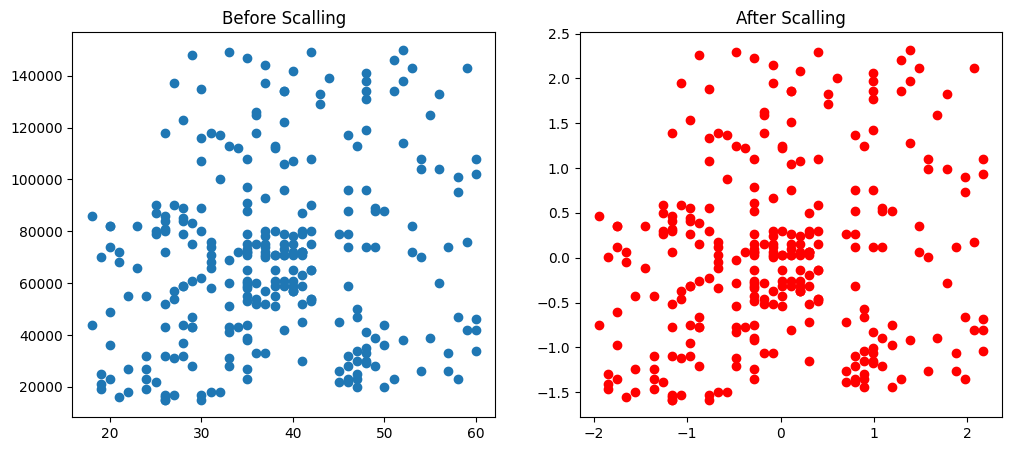

In [23]:
fig, (ax1,ax2) = plt.subplots(ncols = 2, figsize= (12,5))

ax1.scatter(x_train["Age"], x_train["EstimatedSalary"])
ax1.set_title("Before Scalling")
ax2.scatter(x_train_scaled["Age"], x_train_scaled["EstimatedSalary"], color= "red")
ax2.set_title("After Scalling")
plt.show()